In [5]:
# Parse timing output files to extract wall time.
import os, re, glob, pandas as pd

def parse_folder(folder, file_glob='time_*.txt'):
    files = sorted(glob.glob(os.path.join(folder, file_glob)))

    wall_time_rows = []

    real_re = re.compile(r'^real\s+(\d+)m([0-9.]+)s')
    elapsed_re = re.compile(r'Elapsed \(wall clock\) time.*?:\s*([0-9]+:[0-9]+:[0-9]+\.[0-9]+|[0-9]+:[0-9]+\.[0-9]+)')
    wall_simple_re = re.compile(r'(?:Wall time|WallTime|WALL_TIME)[:=]\s*([0-9.]+)\s*s?')
    seconds_only_re = re.compile(r'^TIME_SEC[:=]\s*([0-9.]+)$')
    errors_re = re.compile(r'Segmentation fault|Killed|Aborted', re.IGNORECASE)


    def hms_to_seconds(val: str) -> float:
        parts = val.split(':')
        if len(parts) == 3:
            h, m, s = parts
            return int(h) * 3600 + int(m) * 60 + float(s)
        elif len(parts) == 2:
            m, s = parts
            return int(m) * 60 + float(s)
        else:
            raise ValueError(f'Unexpected time format: {val}')


    def parse_lines(lines):
        for line in lines:
            line = line.strip()
            if not line:
                continue
            m = real_re.search(line)
            if m:
                return float(m.group(1)) * 60 + float(m.group(2)), 'real_m_s', line
            m = elapsed_re.search(line)
            if m:
                return hms_to_seconds(m.group(1)), 'elapsed_hms', line
            m = wall_simple_re.search(line)
            if m:
                return float(m.group(1)), 'wall_simple', line
            m = seconds_only_re.search(line)
            if m:
                return float(m.group(1)), 'seconds_only', line
        return None, None, None

    for f in files:
        try:
            with open(f, 'r', encoding='utf-8', errors='replace') as fh:
                lines = fh.readlines()
            wt, pattern, raw = parse_lines(lines)
            error = wt is None or errors_re.search(''.join(lines)) is not None
            wall_time_rows.append({
                'file': os.path.basename(f),
                'wall_time_seconds': wt,
                'pattern': pattern,
                'raw_line': raw,
                'error': error
            })
        except Exception as e:
            wall_time_rows.append({
                'file': os.path.basename(f),
                'wall_time_seconds': None,
                'pattern': None,
                'raw_line': None,
                'error': True,
                'exception': str(e)
            })

    wall_times_df = pd.DataFrame(wall_time_rows)
    return wall_times_df

In [6]:
ARMS_df = parse_folder('./ARMS').assign(model='ARMS')
model_df = parse_folder('./model').assign(model='model')
times_df = pd.concat([ARMS_df, model_df], ignore_index=True)

In [7]:
# Derive workload and memory size from filename and reorder columns.
import re

workload_size_re = re.compile(r'time_[^_]+_(.+?)_SIZE_([0-9]+[A-Z]+)', re.IGNORECASE)

def extract_workload_size(filename: str):
    m = workload_size_re.search(filename)
    if not m:
        return None, None
    workload, size = m.group(1), m.group(2)
    return workload, size

parsed = times_df['file'].apply(extract_workload_size)
# Expand into two columns
workloads = [p[0] for p in parsed]
sizes = [p[1] for p in parsed]

times_df['workload'] = workloads
times_df['size'] = sizes

# Final ordered view: time, model, workload, size
final_df = times_df[['wall_time_seconds','model','workload','size', 'error']]
final_df

,wall_time_seconds,model,workload,size,error
0,5045.457,ARMS,NAS_bt.D,128MB,False
1,4563.624,ARMS,NAS_bt.D,16GB,False
2,4936.020,ARMS,NAS_bt.D,1GB,False
3,4577.087,ARMS,NAS_bt.D,4GB,False
4,5027.783,ARMS,NAS_bt.D,512MB,False
...,...,...,...,...,...
175,18.008,model,tc.twitter,16GB,False
176,15.334,model,tc.twitter,1GB,False
177,15.865,model,tc.twitter,4GB,False
178,14.993,model,tc.twitter,512MB,False


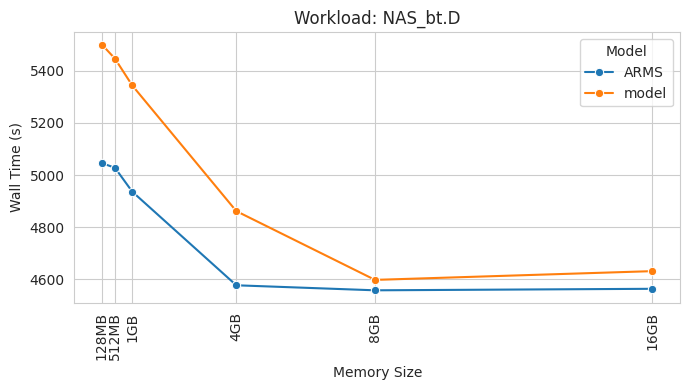

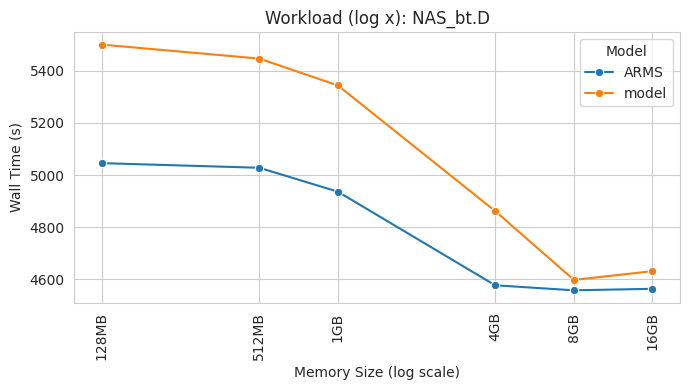

Percent differences (model vs ARMS) for workload: NAS_bt.D


model,size,ARMS,model,pct_diff_model_vs_ARMS
0,128MB,5045.457,5500.005,9.009055
1,512MB,5027.783,5446.436,8.326791
2,1GB,4936.020,5343.274,8.250655
3,4GB,4577.087,4861.524,6.214367
4,8GB,4557.814,4597.785,0.876977
5,16GB,4563.624,4631.359,1.484237


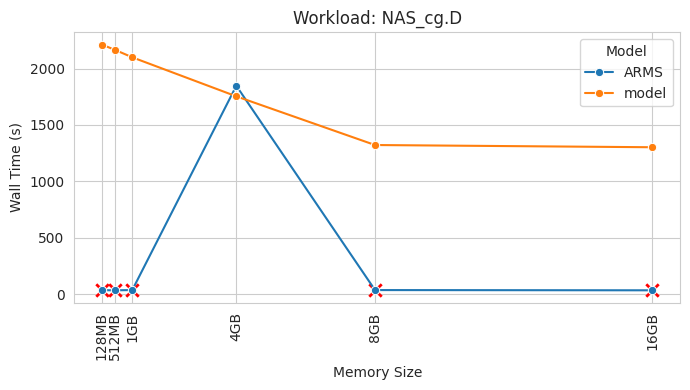

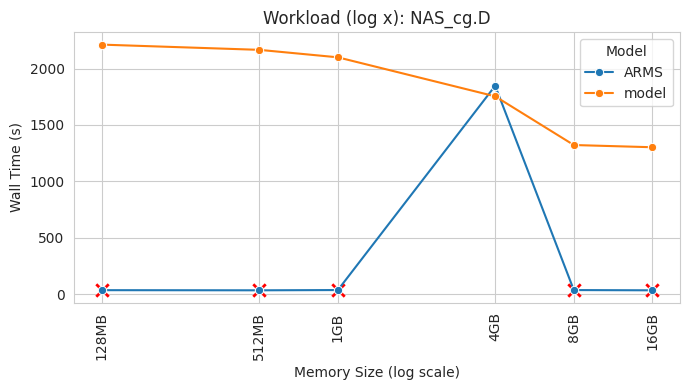

Percent differences (model vs ARMS) for workload: NAS_cg.D


model,size,ARMS,model,pct_diff_model_vs_ARMS
0,128MB,36.156,2211.855,6017.532360
1,512MB,34.955,2165.568,6095.302532
2,1GB,37.217,2099.293,5540.683021
3,4GB,1847.112,1753.576,-5.063905
4,8GB,37.061,1322.229,3467.709992
5,16GB,34.930,1302.512,3628.920699


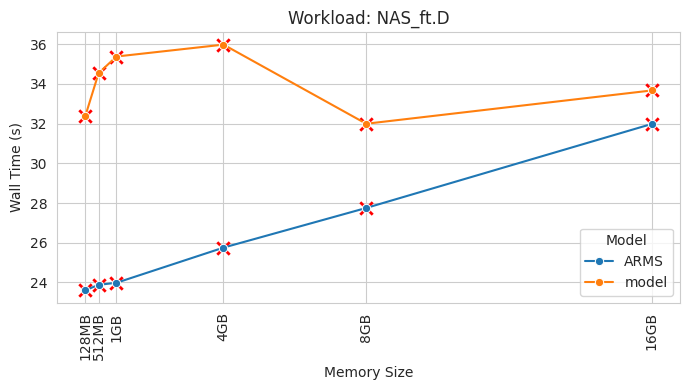

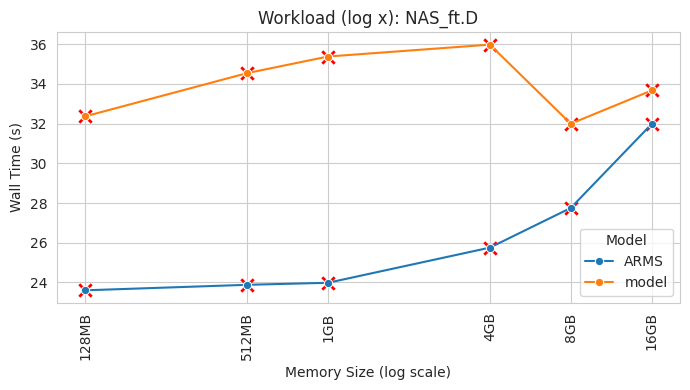

Percent differences (model vs ARMS) for workload: NAS_ft.D


model,size,ARMS,model,pct_diff_model_vs_ARMS
0,128MB,23.602,32.368,37.140920
1,512MB,23.879,34.545,44.666862
2,1GB,23.981,35.382,47.541804
3,4GB,25.753,35.982,39.719644
4,8GB,27.752,31.995,15.288988
5,16GB,31.983,33.672,5.280930


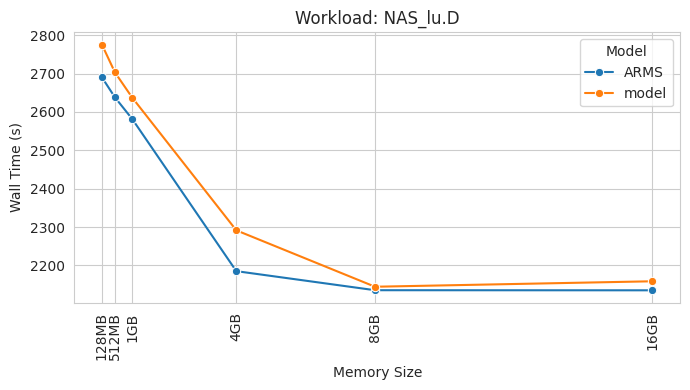

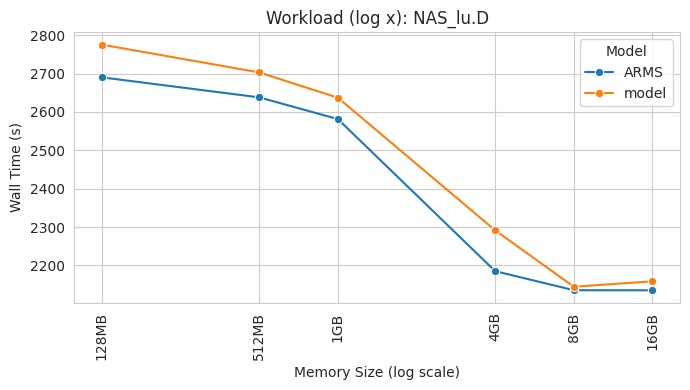

Percent differences (model vs ARMS) for workload: NAS_lu.D


model,size,ARMS,model,pct_diff_model_vs_ARMS
0,128MB,2690.271,2775.563,3.170387
1,512MB,2638.124,2703.143,2.464592
2,1GB,2581.507,2637.260,2.159707
3,4GB,2185.208,2291.594,4.868461
4,8GB,2135.525,2144.571,0.423596
5,16GB,2135.265,2158.812,1.102767


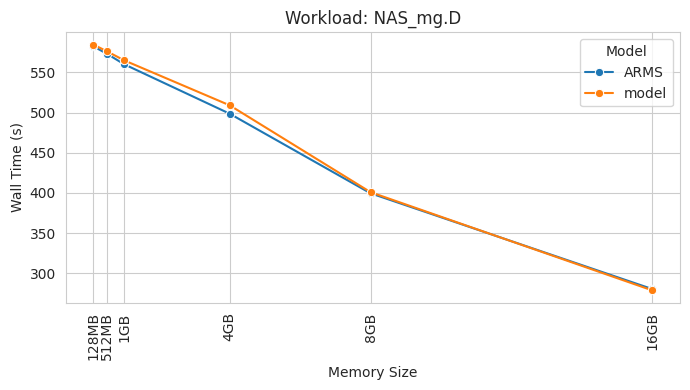

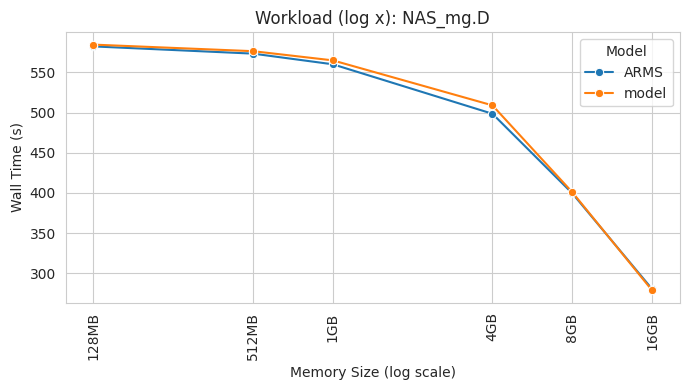

Percent differences (model vs ARMS) for workload: NAS_mg.D


model,size,ARMS,model,pct_diff_model_vs_ARMS
0,128MB,582.217,584.445,0.382675
1,512MB,573.245,576.280,0.529442
2,1GB,559.972,564.841,0.869508
3,4GB,498.460,508.901,2.094652
4,8GB,399.579,400.942,0.341109
5,16GB,280.581,278.938,-0.585571


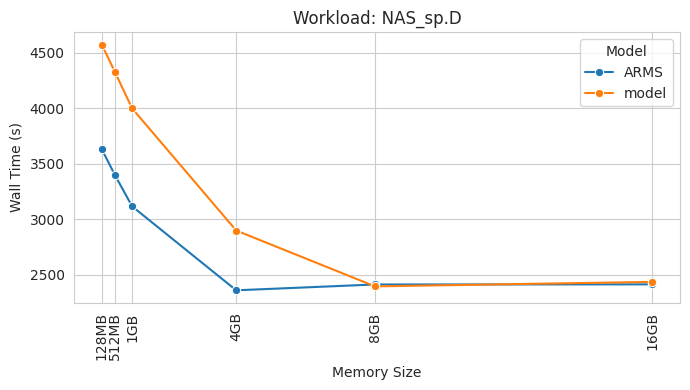

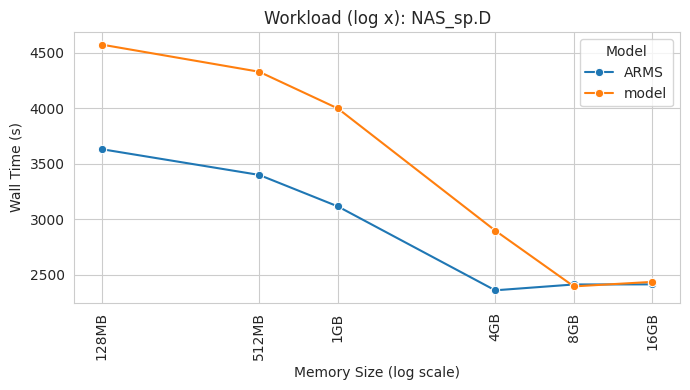

Percent differences (model vs ARMS) for workload: NAS_sp.D


model,size,ARMS,model,pct_diff_model_vs_ARMS
0,128MB,3630.150,4572.402,25.956283
1,512MB,3398.467,4327.935,27.349626
2,1GB,3114.769,3997.297,28.333658
3,4GB,2358.668,2897.427,22.841663
4,8GB,2411.229,2394.182,-0.706984
5,16GB,2412.268,2434.598,0.925685


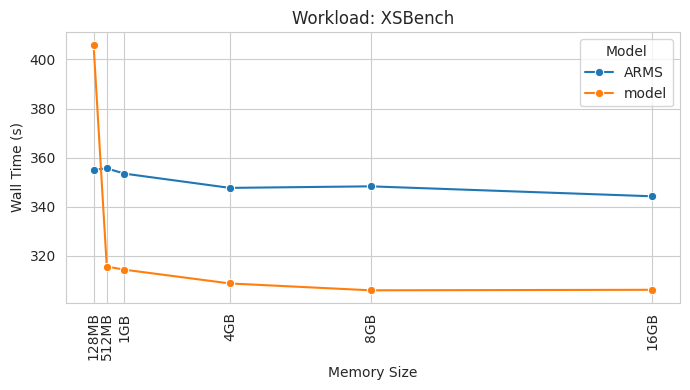

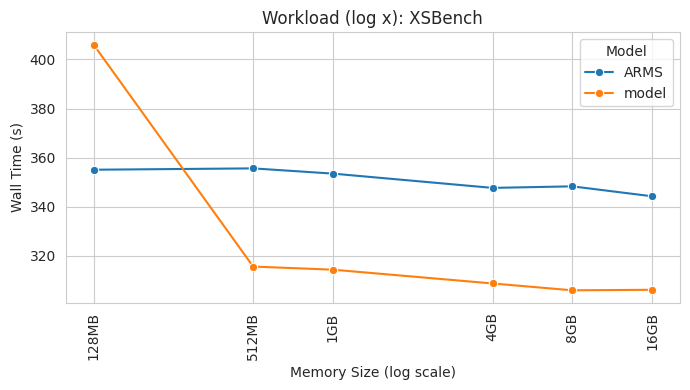

Percent differences (model vs ARMS) for workload: XSBench


model,size,ARMS,model,pct_diff_model_vs_ARMS
0,128MB,355.071,406.039,14.354312
1,512MB,355.620,315.626,-11.246274
2,1GB,353.488,314.350,-11.071946
3,4GB,347.672,308.740,-11.197911
4,8GB,348.303,305.947,-12.160676
5,16GB,344.255,306.156,-11.067087


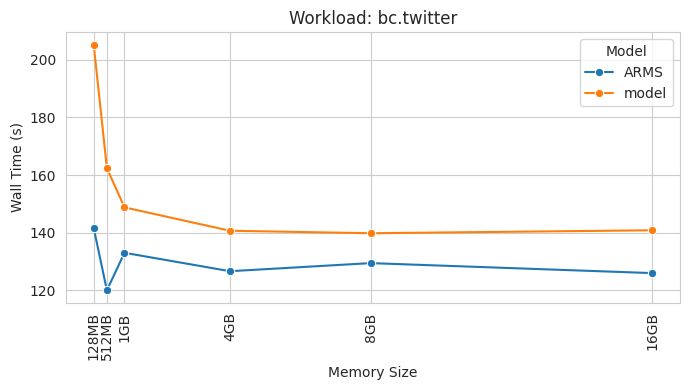

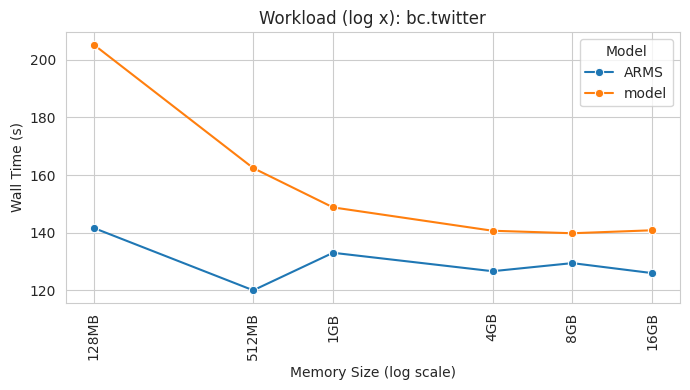

Percent differences (model vs ARMS) for workload: bc.twitter


model,size,ARMS,model,pct_diff_model_vs_ARMS
0,128MB,141.622,205.255,44.931578
1,512MB,119.978,162.401,35.358982
2,1GB,133.006,148.763,11.846834
3,4GB,126.608,140.654,11.094086
4,8GB,129.419,139.787,8.011188
5,16GB,125.952,140.811,11.797351


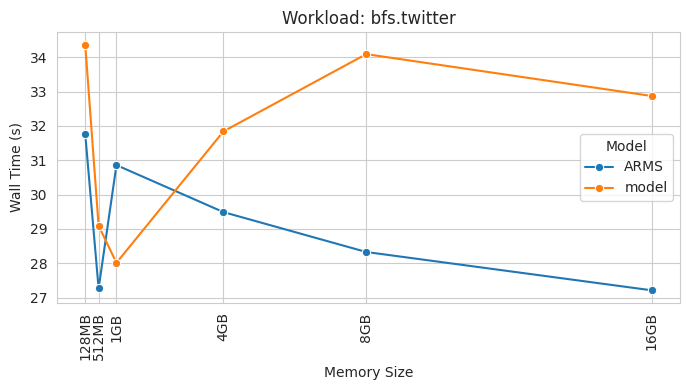

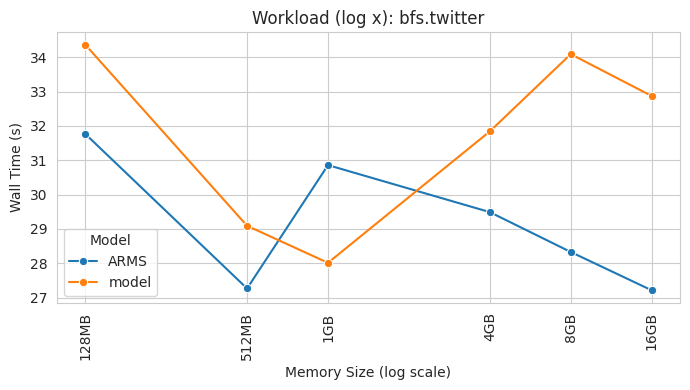

Percent differences (model vs ARMS) for workload: bfs.twitter


model,size,ARMS,model,pct_diff_model_vs_ARMS
0,128MB,31.767,34.366,8.181446
1,512MB,27.264,29.090,6.697477
2,1GB,30.857,28.011,-9.223191
3,4GB,29.488,31.840,7.976126
4,8GB,28.327,34.089,20.341017
5,16GB,27.211,32.870,20.796737


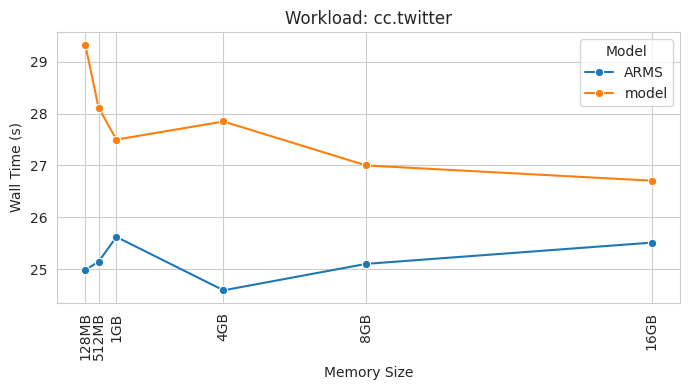

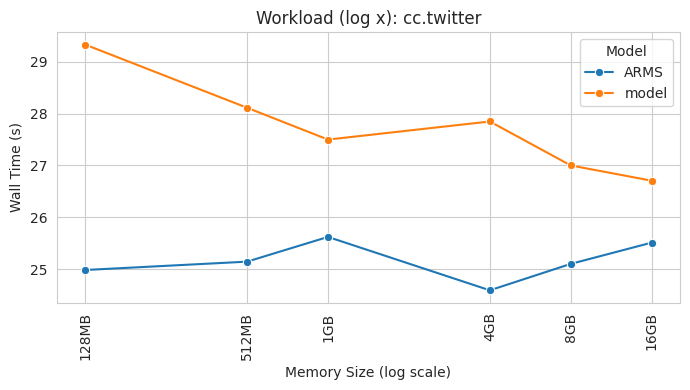

Percent differences (model vs ARMS) for workload: cc.twitter


model,size,ARMS,model,pct_diff_model_vs_ARMS
0,128MB,24.984,29.332,17.403138
1,512MB,25.145,28.114,11.807516
2,1GB,25.622,27.500,7.329639
3,4GB,24.592,27.849,13.244144
4,8GB,25.102,27.001,7.565134
5,16GB,25.512,26.707,4.684070


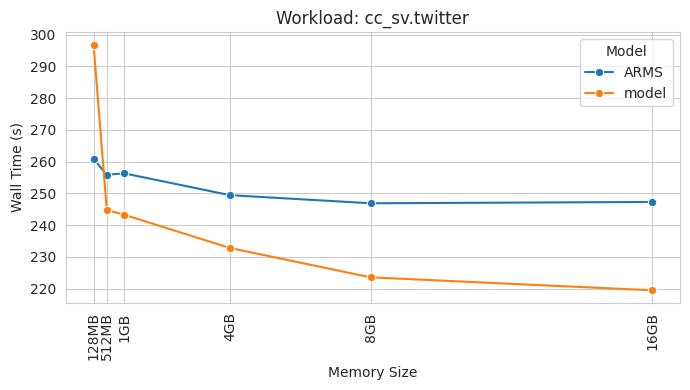

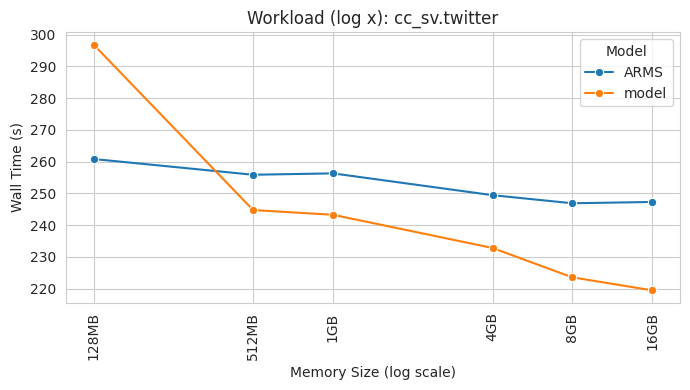

Percent differences (model vs ARMS) for workload: cc_sv.twitter


model,size,ARMS,model,pct_diff_model_vs_ARMS
0,128MB,260.830,296.848,13.808994
1,512MB,255.874,244.760,-4.343544
2,1GB,256.309,243.274,-5.085658
3,4GB,249.446,232.821,-6.664769
4,8GB,246.895,223.577,-9.444501
5,16GB,247.308,219.490,-11.248322


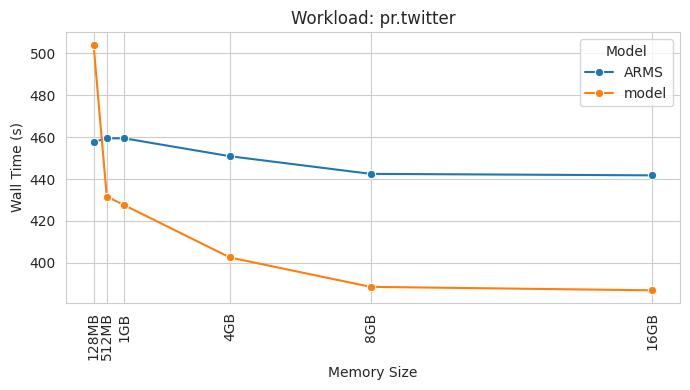

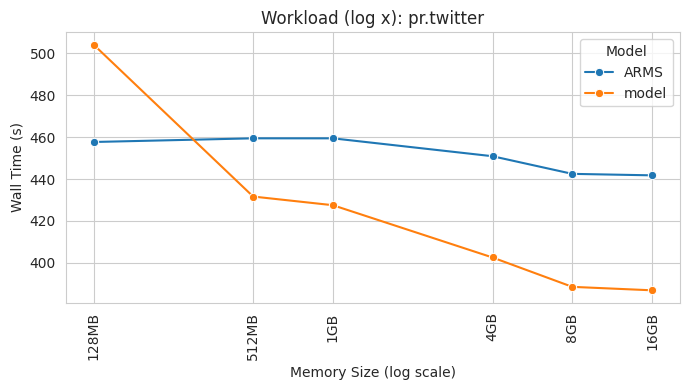

Percent differences (model vs ARMS) for workload: pr.twitter


model,size,ARMS,model,pct_diff_model_vs_ARMS
0,128MB,457.672,504.108,10.146131
1,512MB,459.422,431.658,-6.043246
2,1GB,459.416,427.524,-6.941857
3,4GB,450.887,402.601,-10.709113
4,8GB,442.475,388.591,-12.177863
5,16GB,441.768,386.941,-12.410813


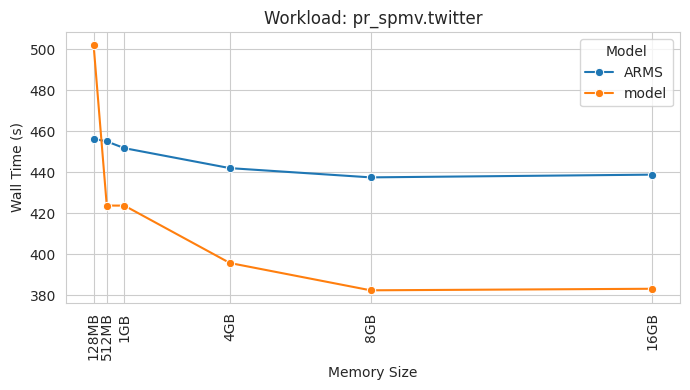

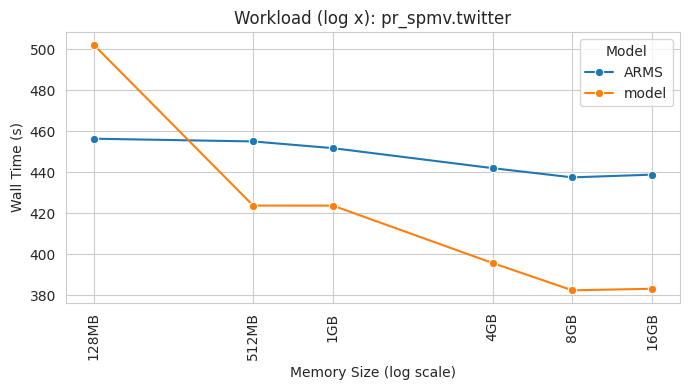

Percent differences (model vs ARMS) for workload: pr_spmv.twitter


model,size,ARMS,model,pct_diff_model_vs_ARMS
0,128MB,456.396,502.339,10.066477
1,512MB,455.064,423.746,-6.882109
2,1GB,451.782,423.723,-6.210739
3,4GB,442.026,395.694,-10.481736
4,8GB,437.512,382.363,-12.605140
5,16GB,438.846,383.119,-12.698532


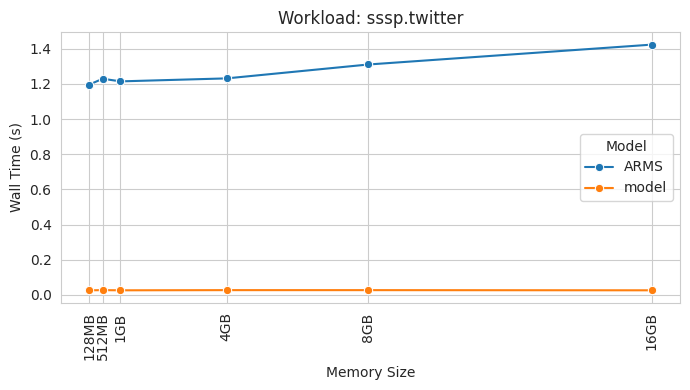

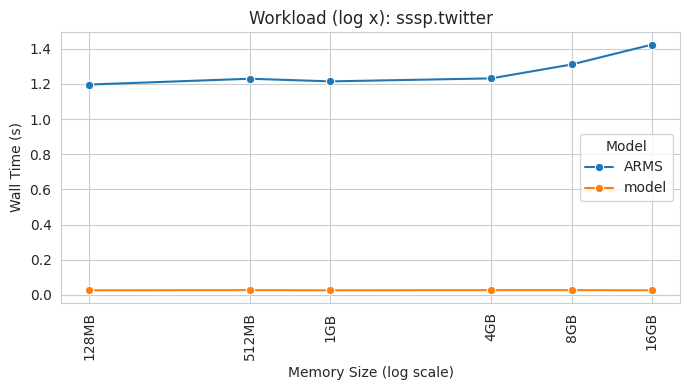

Percent differences (model vs ARMS) for workload: sssp.twitter


model,size,ARMS,model,pct_diff_model_vs_ARMS
0,128MB,1.196,0.026,-97.826087
1,512MB,1.229,0.027,-97.803092
2,1GB,1.214,0.026,-97.858320
3,4GB,1.231,0.027,-97.806661
4,8GB,1.310,0.027,-97.938931
5,16GB,1.423,0.026,-98.172874


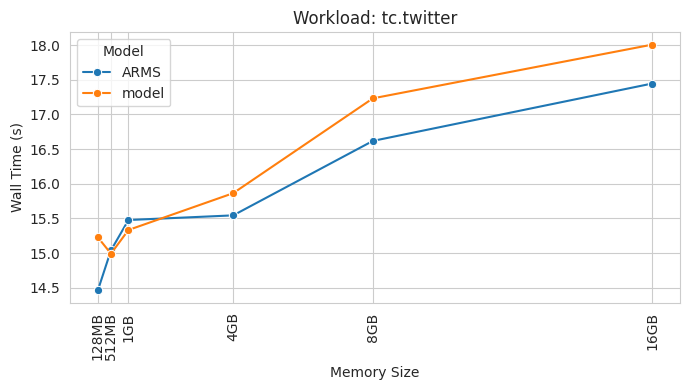

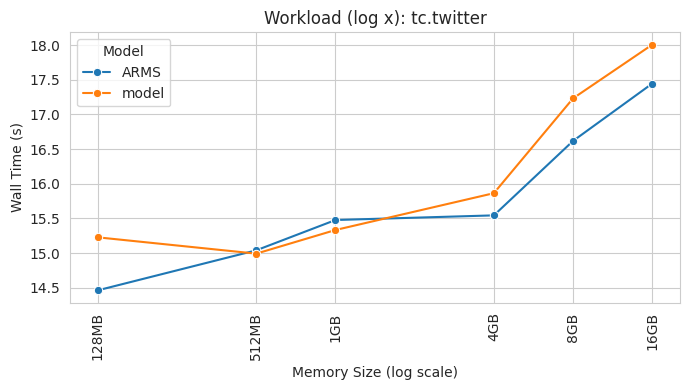

Percent differences (model vs ARMS) for workload: tc.twitter


model,size,ARMS,model,pct_diff_model_vs_ARMS
0,128MB,14.464,15.228,5.282080
1,512MB,15.041,14.993,-0.319128
2,1GB,15.478,15.334,-0.930353
3,4GB,15.545,15.865,2.058540
4,8GB,16.619,17.233,3.694566
5,16GB,17.447,18.008,3.215453


Summary of percent differences across workloads:


model,size,ARMS,model,pct_diff_model_vs_ARMS,workload
0,128MB,5045.457,5500.005,9.009055,NAS_bt.D
1,512MB,5027.783,5446.436,8.326791,NAS_bt.D
2,1GB,4936.020,5343.274,8.250655,NAS_bt.D
3,4GB,4577.087,4861.524,6.214367,NAS_bt.D
4,8GB,4557.814,4597.785,0.876977,NAS_bt.D
...,...,...,...,...,...
85,512MB,15.041,14.993,-0.319128,tc.twitter
86,1GB,15.478,15.334,-0.930353,tc.twitter
87,4GB,15.545,15.865,2.058540,tc.twitter
88,8GB,16.619,17.233,3.694566,tc.twitter


In [8]:
# Plot per-workload performance across sizes (linear + log) and show percent differences.
import matplotlib.pyplot as plt
import seaborn as sns
import math, re
from IPython.display import display

if 'final_df' not in globals():
    raise RuntimeError('final_df not found. Run previous cells first.')

size_re = re.compile(r'^(\d+)([KMG]B)$', re.IGNORECASE)
mult = {'KB': 1024, 'MB': 1024**2, 'GB': 1024**3}

def size_to_bytes(val):
    if not isinstance(val, str):
        return math.nan
    m = size_re.match(val.strip())
    if not m:
        return math.nan
    num = int(m.group(1))
    unit = m.group(2).upper()
    return num * mult[unit]

def bytes_to_label(b):
    if b % mult['GB'] == 0:
        return f"{int(b / mult['GB'])}GB"
    if b % mult['MB'] == 0:
        return f"{int(b / mult['MB'])}MB"
    if b % mult['KB'] == 0:
        return f"{int(b / mult['KB'])}KB"
    return str(b)

plot_df = final_df.copy()
plot_df['size_bytes'] = plot_df['size'].apply(size_to_bytes)
plot_df = plot_df.dropna(subset=['workload', 'size_bytes'])

workloads = sorted(plot_df['workload'].unique())

sns.set_style('whitegrid')

percent_tables = {}

for wl in workloads:
    dfw = plot_df[plot_df['workload'] == wl].sort_values('size_bytes')
    if dfw.empty:
        continue
    # Percent difference table (model vs ARMS)
    pivot = dfw.pivot_table(index='size_bytes', columns='model', values='wall_time_seconds')
    if {'ARMS','model'}.issubset(pivot.columns):
        pivot['pct_diff_model_vs_ARMS'] = (pivot['model'] - pivot['ARMS']) / pivot['ARMS'] * 100.0
        pct_df = pivot.reset_index().rename(columns={'size_bytes':'size_bytes_raw'})
        pct_df['size'] = pct_df['size_bytes_raw'].apply(bytes_to_label)
        pct_df = pct_df[['size','ARMS','model','pct_diff_model_vs_ARMS']]
        percent_tables[wl] = pct_df
    else:
        percent_tables[wl] = None

    # Linear scale plot
    plt.figure(figsize=(7,4))
    ax = sns.lineplot(data=dfw, x='size_bytes', y='wall_time_seconds', hue='model', marker='o')
    err_rows = dfw[(dfw['error']) & dfw['wall_time_seconds'].notna()]
    if not err_rows.empty:
        for _, r in err_rows.iterrows():
            ax.scatter(r['size_bytes'], r['wall_time_seconds'], marker='x', s=80, color='red', linewidths=2)
    ticks = sorted(dfw['size_bytes'].unique())
    ax.set_xticks(ticks)
    ax.set_xticklabels([bytes_to_label(t) for t in ticks])
    for lbl in ax.get_xticklabels():
        lbl.set_rotation(90)
    ax.set_title(f'Workload: {wl}')
    ax.set_xlabel('Memory Size')
    ax.set_ylabel('Wall Time (s)')
    ax.legend(title='Model')
    plt.tight_layout()
    plt.show()

    # Log scale plot
    plt.figure(figsize=(7,4))
    ax = sns.lineplot(data=dfw, x='size_bytes', y='wall_time_seconds', hue='model', marker='o')
    err_rows = dfw[(dfw['error']) & dfw['wall_time_seconds'].notna()]
    if not err_rows.empty:
        for _, r in err_rows.iterrows():
            ax.scatter(r['size_bytes'], r['wall_time_seconds'], marker='x', s=80, color='red', linewidths=2)
    ticks = sorted(dfw['size_bytes'].unique())
    ax.set_xscale('log')
    ax.set_xticks(ticks)
    ax.set_xticklabels([bytes_to_label(t) for t in ticks])
    for lbl in ax.get_xticklabels():
        lbl.set_rotation(90)
    ax.set_title(f'Workload (log x): {wl}')
    ax.set_xlabel('Memory Size (log scale)')
    ax.set_ylabel('Wall Time (s)')
    ax.legend(title='Model')
    plt.tight_layout()
    plt.show()

    # Display percent differences table
    if percent_tables[wl] is not None:
        print(f"Percent differences (model vs ARMS) for workload: {wl}")
        display(percent_tables[wl])
    else:
        print(f"Percent differences unavailable (missing both models) for workload: {wl}")

# Collect all tables optionally into a single concatenated DataFrame
all_pct = []
for wl, tbl in percent_tables.items():
    if tbl is not None:
        t = tbl.copy()
        t['workload'] = wl
        all_pct.append(t)
if all_pct:
    percent_diff_df = pd.concat(all_pct, ignore_index=True)
    print('Summary of percent differences across workloads:')
    display(percent_diff_df)
